# Sistema difuso — Riesgo de incendio forestal

Notebook de un sistema de inferencia **Mamdani** implementado con
[scikit-fuzzy](https://scikit-fuzzy.readthedocs.io/). Estima un índice de
riesgo de incendio forestal a partir de tres variables ambientales:

| Entrada | Universo | Conjuntos |
|---|---|---|
| Temperatura | 0 – 45 °C | baja / media / alta |
| Humedad relativa | 0 – 100 % | baja / media / alta |
| Viento | 0 – 60 km/h | suave / moderado / fuerte |

| Salida | Universo | Conjuntos |
|---|---|---|
| Riesgo | 0 – 100 | bajo / moderado / alto / extremo |

El problema encaja bien en lógica difusa: las fronteras entre “hace calor”
o “hay poco viento” no son binarias, y un experto razona con reglas del tipo
*“si hace mucho calor, el ambiente está muy seco y sopla viento fuerte,
entonces el riesgo es extremo”*.


## 1. Dependencias

Ejecuta las celdas en orden. El motor de inferencia, las gráficas y los
casos de prueba viven en este notebook (no hace falta ningún `.py` aparte).


In [1]:
%matplotlib inline

import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
from skfuzzy.control.visualization import FuzzyVariableVisualizer

import matplotlib.pyplot as plt
from IPython.display import display, Markdown


## 2. Universos de discurso y variables lingüísticas

Cada variable se define sobre un universo continuo (discretizado a 0.1)
y luego se etiquetan sus conjuntos difusos.


In [2]:
UNIVERSO_TEMPERATURA = np.arange(0, 45.01, 0.1)
UNIVERSO_HUMEDAD = np.arange(0, 100.01, 0.1)
UNIVERSO_VIENTO = np.arange(0, 60.01, 0.1)
UNIVERSO_RIESGO = np.arange(0, 100.01, 0.1)

temperatura = ctrl.Antecedent(UNIVERSO_TEMPERATURA, "temperatura")
humedad = ctrl.Antecedent(UNIVERSO_HUMEDAD, "humedad")
viento = ctrl.Antecedent(UNIVERSO_VIENTO, "viento")
riesgo = ctrl.Consequent(UNIVERSO_RIESGO, "riesgo")


## 3. Funciones de pertenencia

Todas son **triangulares** (`fuzz.trimf`), definidas por tres vértices
`[a, b, c]`. Se superponen a propósito para que el paso entre categorías
sea gradual.

**Temperatura (°C):** `baja [0, 0, 20]`, `media [10, 22, 34]`, `alta [25, 45, 45]`

**Humedad (%):** `baja [0, 0, 35]`, `media [20, 50, 80]`, `alta [65, 100, 100]`

**Viento (km/h):** `suave [0, 0, 15]`, `moderado [8, 25, 42]`, `fuerte [30, 60, 60]`

**Riesgo (0–100):** `bajo [0, 0, 30]`, `moderado [15, 40, 65]`, `alto [50, 70, 90]`, `extremo [75, 100, 100]`


In [3]:
temperatura["baja"] = fuzz.trimf(temperatura.universe, [0, 0, 20])
temperatura["media"] = fuzz.trimf(temperatura.universe, [10, 22, 34])
temperatura["alta"] = fuzz.trimf(temperatura.universe, [25, 45, 45])

humedad["baja"] = fuzz.trimf(humedad.universe, [0, 0, 35])
humedad["media"] = fuzz.trimf(humedad.universe, [20, 50, 80])
humedad["alta"] = fuzz.trimf(humedad.universe, [65, 100, 100])

viento["suave"] = fuzz.trimf(viento.universe, [0, 0, 15])
viento["moderado"] = fuzz.trimf(viento.universe, [8, 25, 42])
viento["fuerte"] = fuzz.trimf(viento.universe, [30, 60, 60])

riesgo["bajo"] = fuzz.trimf(riesgo.universe, [0, 0, 30])
riesgo["moderado"] = fuzz.trimf(riesgo.universe, [15, 40, 65])
riesgo["alto"] = fuzz.trimf(riesgo.universe, [50, 70, 90])
riesgo["extremo"] = fuzz.trimf(riesgo.universe, [75, 100, 100])

# Defuzzificación por centroide (centro de gravedad del área agregada)
riesgo.defuzzify_method = "centroid"


### Visualización de las funciones de pertenencia


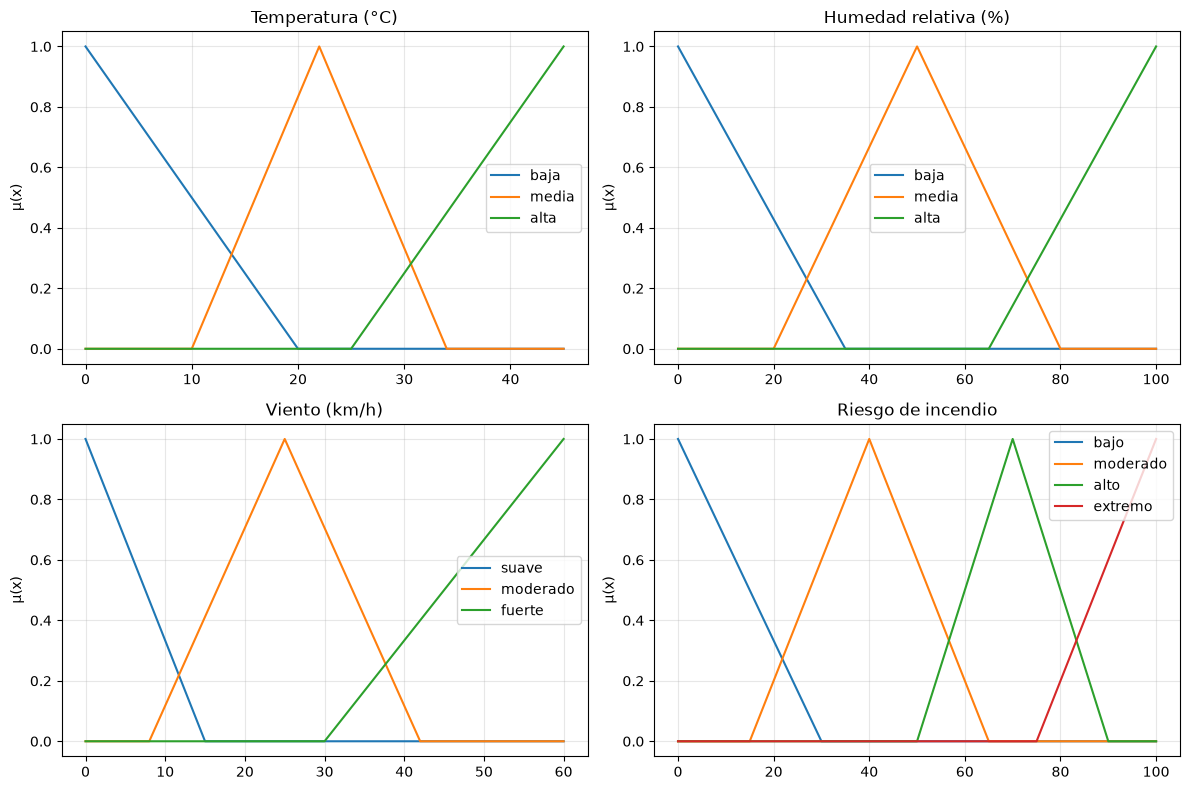

In [4]:
fig, ejes = plt.subplots(2, 2, figsize=(12, 8))

pares = [
    (ejes[0, 0], temperatura, "Temperatura (°C)"),
    (ejes[0, 1], humedad, "Humedad relativa (%)"),
    (ejes[1, 0], viento, "Viento (km/h)"),
    (ejes[1, 1], riesgo, "Riesgo de incendio"),
]

for ax, variable, titulo in pares:
    for nombre in variable.terms:
        ax.plot(variable.universe, variable[nombre].mf, label=nombre)
    ax.set_title(titulo)
    ax.set_ylabel("μ(x)")
    ax.set_ylim(-0.05, 1.05)
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()


## 4. Base de reglas (4 reglas)

Tipo **Mamdani**: AND = mínimo, agregación = máximo, defuzzificación = centroide.

- **R1** asigna riesgo bajo cuando la humedad es alta.
- **R2** asigna riesgo moderado cuando la temperatura es baja o media y la
  humedad es baja o media.
- **R3** asigna riesgo alto ante temperatura alta con humedad media, o con
  humedad baja y viento suave o moderado.
- **R4** reserva el riesgo extremo para la combinación crítica de temperatura
  alta, humedad baja y viento fuerte.


In [5]:
reglas = [
    ctrl.Rule(humedad["alta"], riesgo["bajo"]),
    ctrl.Rule(
        (temperatura["baja"] | temperatura["media"])
        & (humedad["baja"] | humedad["media"]),
        riesgo["moderado"],
    ),
    ctrl.Rule(
        temperatura["alta"]
        & (
            humedad["media"]
            | (humedad["baja"] & (viento["suave"] | viento["moderado"]))
        ),
        riesgo["alto"],
    ),
    ctrl.Rule(
        temperatura["alta"] & humedad["baja"] & viento["fuerte"],
        riesgo["extremo"],
    ),
]

DESCRIPCION_REGLAS = [
    "R1: SI humedad es ALTA ENTONCES riesgo es BAJO",
    ("R2: SI temperatura es BAJA O MEDIA Y humedad es BAJA O MEDIA "
     "ENTONCES riesgo es MODERADO"),
    ("R3: SI temperatura es ALTA Y (humedad es MEDIA O (humedad es BAJA "
     "Y viento es SUAVE O MODERADO)) ENTONCES riesgo es ALTO"),
    ("R4: SI temperatura es ALTA Y humedad es BAJA Y viento es FUERTE "
     "ENTONCES riesgo es EXTREMO"),
]

sistema_control = ctrl.ControlSystem(reglas)

for linea in DESCRIPCION_REGLAS:
    print(linea)


R1: SI humedad es ALTA ENTONCES riesgo es BAJO
R2: SI temperatura es BAJA O MEDIA Y humedad es BAJA O MEDIA ENTONCES riesgo es MODERADO
R3: SI temperatura es ALTA Y (humedad es MEDIA O (humedad es BAJA Y viento es SUAVE O MODERADO)) ENTONCES riesgo es ALTO
R4: SI temperatura es ALTA Y humedad es BAJA Y viento es FUERTE ENTONCES riesgo es EXTREMO


## 5. Motor de inferencia

`evaluar_riesgo` corre una simulación Mamdani y, sobre el valor crisp
(0–100), calcula el grado de pertenencia a cada categoría de salida.
La **categoría dominante** es la de mayor pertenencia.


In [6]:
CATEGORIAS_RIESGO = ["bajo", "moderado", "alto", "extremo"]
COLOR_POR_CATEGORIA = {
    "bajo": "#2ecc71",
    "moderado": "#f1c40f",
    "alto": "#e67e22",
    "extremo": "#e74c3c",
}


def categorizar_riesgo(valor_riesgo: float) -> tuple[str, dict[str, float]]:
    grados = {
        nombre: float(
            fuzz.interp_membership(
                riesgo.universe, riesgo[nombre].mf, valor_riesgo
            )
        )
        for nombre in CATEGORIAS_RIESGO
    }
    categoria = max(grados, key=grados.get)
    return categoria, grados


def evaluar_riesgo(
    valor_temperatura: float, valor_humedad: float, valor_viento: float
):
    simulacion = ctrl.ControlSystemSimulation(sistema_control)
    simulacion.input["temperatura"] = float(valor_temperatura)
    simulacion.input["humedad"] = float(valor_humedad)
    simulacion.input["viento"] = float(valor_viento)
    simulacion.compute()

    valor = float(simulacion.output["riesgo"])
    categoria, grados = categorizar_riesgo(valor)
    return {
        "temperatura": valor_temperatura,
        "humedad": valor_humedad,
        "viento": valor_viento,
        "valor_riesgo": valor,
        "categoria": categoria,
        "grados_categoria": grados,
        "simulacion": simulacion,
    }


def mostrar_resultado(resultado: dict) -> None:
    categoria = resultado["categoria"]
    color = COLOR_POR_CATEGORIA[categoria]
    grados = ", ".join(
        f"{nombre}={grado:.2f}"
        for nombre, grado in resultado["grados_categoria"].items()
    )
    display(Markdown(
        f"### Riesgo: **{resultado['valor_riesgo']:.2f} / 100** — "
        f"<span style='color:white;background:{color};padding:4px 10px;"
        f"border-radius:6px;font-weight:bold'>{categoria.upper()}</span>\n\n"
        f"Entradas: temperatura = {resultado['temperatura']} °C, "
        f"humedad = {resultado['humedad']} %, "
        f"viento = {resultado['viento']} km/h\n\n"
        f"Pertenencias de la salida: {grados}"
    ))


def graficar_inferencia(simulacion) -> None:
    variables = [
        (temperatura, "Fuzzificación — Temperatura"),
        (humedad, "Fuzzificación — Humedad"),
        (viento, "Fuzzificación — Viento"),
        (riesgo, "Agregación y defuzzificación — Riesgo"),
    ]
    for variable, titulo in variables:
        fig, ax = FuzzyVariableVisualizer(variable).view(sim=simulacion)
        ax.set_title(titulo)
        fig.set_size_inches(8, 3.4)
        fig.tight_layout()
        plt.show()
        plt.close(fig)


## 6. Evaluación interactiva

Cambia los tres deslizadores y pulsa el botón para recalcular. Las gráficas
muestran la fuzzificación de cada entrada (línea vertical = valor crisp) y
la agregación de la salida con el centroide.


In [7]:
from ipywidgets import FloatSlider, Button, VBox, HBox, Output

salida_interactiva = Output()

slider_temp = FloatSlider(
    value=24, min=0, max=45, step=0.5,
    description="Temp. (°C)", continuous_update=False,
    style={"description_width": "110px"}, layout={"width": "420px"},
)
slider_hum = FloatSlider(
    value=45, min=0, max=100, step=0.5,
    description="Humedad (%)", continuous_update=False,
    style={"description_width": "110px"}, layout={"width": "420px"},
)
slider_viento = FloatSlider(
    value=15, min=0, max=60, step=0.5,
    description="Viento (km/h)", continuous_update=False,
    style={"description_width": "110px"}, layout={"width": "420px"},
)
boton_calcular = Button(description="Calcular riesgo", button_style="primary")


def _calcular_interactivo(_=None):
    with salida_interactiva:
        salida_interactiva.clear_output(wait=True)
        resultado = evaluar_riesgo(
            slider_temp.value, slider_hum.value, slider_viento.value
        )
        mostrar_resultado(resultado)
        graficar_inferencia(resultado["simulacion"])


boton_calcular.on_click(_calcular_interactivo)
_calcular_interactivo()

display(VBox([
    slider_temp, slider_hum, slider_viento,
    HBox([boton_calcular]),
    salida_interactiva,
]))


## 7. Evaluación puntual (sin widgets)

Si prefieres no usar deslizadores, cambia estos tres valores y vuelve a
ejecutar la celda.


### Riesgo: **90.28 / 100** — <span style='color:white;background:#e74c3c;padding:4px 10px;border-radius:6px;font-weight:bold'>EXTREMO</span>

Entradas: temperatura = 40 °C, humedad = 10 %, viento = 45 km/h

Pertenencias de la salida: bajo=0.00, moderado=0.00, alto=0.00, extremo=0.61

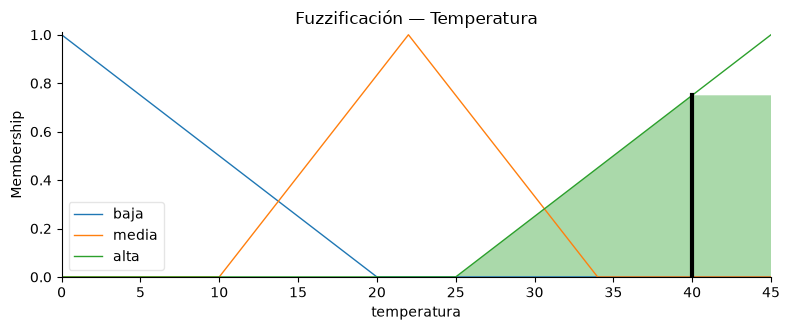

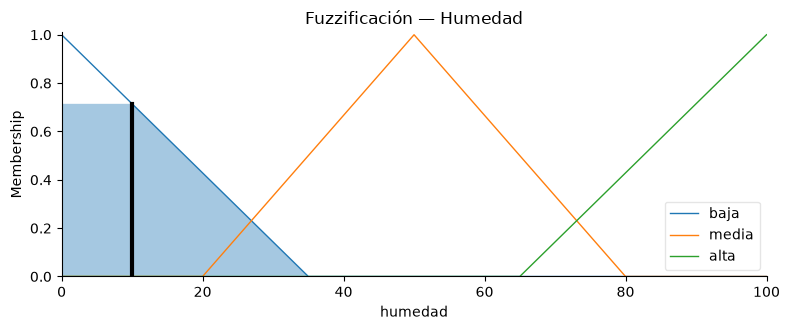

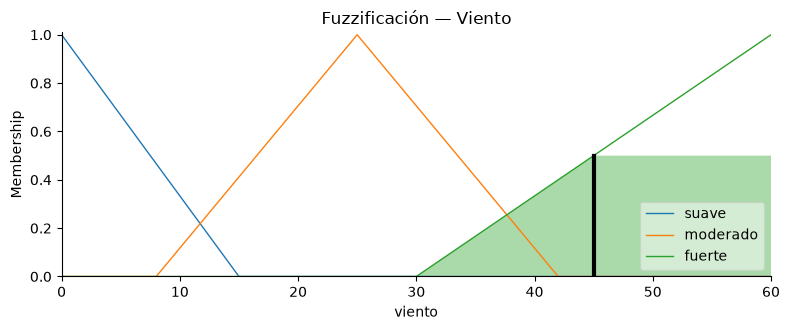

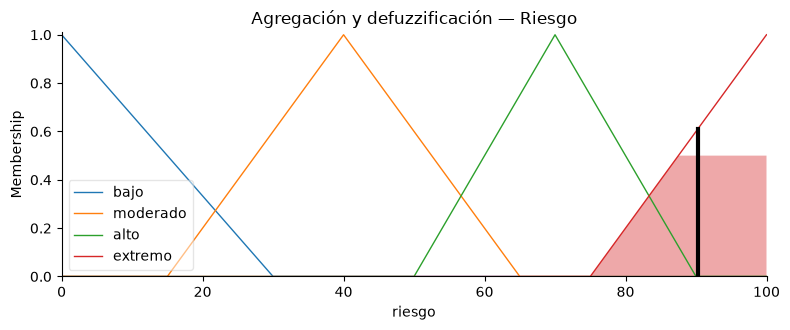

In [8]:
TEMPERATURA = 40   # °C
HUMEDAD = 10       # %
VIENTO = 45        # km/h

resultado = evaluar_riesgo(TEMPERATURA, HUMEDAD, VIENTO)
mostrar_resultado(resultado)
graficar_inferencia(resultado["simulacion"])


## 8. Casos de prueba

Cinco escenarios representativos. Se espera:

| Escenario | T (°C) | H (%) | V (km/h) | Riesgo ≈ | Categoría |
|---|---|---|---|---|---|
| Día fresco y húmedo, sin viento | 12 | 85 | 5 | 11.3 | BAJO |
| Día templado, humedad media, viento moderado | 24 | 50 | 20 | 40.0 | MODERADO |
| Ola de calor, muy seco, viento fuerte | 40 | 10 | 45 | 90.3 | EXTREMO |
| Calor alto pero humedad alta (post-lluvia) | 32 | 90 | 10 | 10.6 | BAJO |
| Frío, seco, viento fuerte (invierno ventoso) | 5 | 15 | 50 | 40.0 | MODERADO |

La humedad alta reduce el riesgo incluso con calor (caso 4). La combinación
de calor, sequedad y viento fuerte activa el nivel extremo (caso 3).


In [9]:
CASOS = [
    ("Día fresco y húmedo, sin viento", 12, 85, 5),
    ("Día templado, humedad media, viento moderado", 24, 50, 20),
    ("Ola de calor, muy seco, viento fuerte", 40, 10, 45),
    ("Calor alto pero humedad alta (post-lluvia)", 32, 90, 10),
    ("Frío, seco, viento fuerte (invierno ventoso)", 5, 15, 50),
]

filas = []
for descripcion, temp, hum, vien in CASOS:
    r = evaluar_riesgo(temp, hum, vien)
    filas.append(
        f"| {descripcion} | {temp} | {hum} | {vien} | "
        f"{r['valor_riesgo']:.2f} | {r['categoria'].upper()} |"
    )

tabla = (
    "| Escenario | T (°C) | H (%) | V (km/h) | Riesgo | Categoría |\n"
    "|---|---|---|---|---|---|\n"
    + "\n".join(filas)
)
display(Markdown(tabla))


| Escenario | T (°C) | H (%) | V (km/h) | Riesgo | Categoría |
|---|---|---|---|---|---|
| Día fresco y húmedo, sin viento | 12 | 85 | 5 | 11.29 | BAJO |
| Día templado, humedad media, viento moderado | 24 | 50 | 20 | 40.00 | MODERADO |
| Ola de calor, muy seco, viento fuerte | 40 | 10 | 45 | 90.28 | EXTREMO |
| Calor alto pero humedad alta (post-lluvia) | 32 | 90 | 10 | 10.63 | BAJO |
| Frío, seco, viento fuerte (invierno ventoso) | 5 | 15 | 50 | 40.00 | MODERADO |

## 9. Conclusiones

- La lógica difusa modela un criterio experto (temperatura + humedad +
  viento → riesgo) sin los saltos artificiales de umbrales booleanos.
- Las visualizaciones de fuzzificación y agregación sirven tanto para
  depurar las funciones de pertenencia como para justificar la base de
  reglas.
- Este notebook concentra definición, inferencia, exploración interactiva
  y casos de prueba en un solo artefacto reproducible.

**Referencias**

- [Documentación de scikit-fuzzy](https://scikit-fuzzy.readthedocs.io/)
- [Repositorio de scikit-fuzzy](https://github.com/scikit-fuzzy/scikit-fuzzy)
